# Sentiment Analysis of Strava Reviews Using (Aspect Mining)

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
df_reviews = pd.read_csv("data/strava_reviews.csv")
display(df_reviews.head(10), df_reviews.describe(), df_reviews.shape)

,review,rating,date
0,Awsomeeee,5,2026-04-05T20:48:27-07:00
1,Paid for a subscription and it never unlocked ...,1,2026-04-05T20:25:07-07:00
2,I was immediately charged $80 for what was sup...,1,2026-04-05T18:43:31-07:00
3,The majority of the app has turned into a sche...,1,2026-04-05T12:55:19-07:00
4,Love the app but I CANNOT STAND how much it bu...,3,2026-04-04T15:41:38-07:00
5,I connected my heart rate monitor to the app. ...,1,2026-04-04T11:20:49-07:00
6,freetrailfretrail freetrailfretrail freetrailf...,1,2026-04-04T07:27:25-07:00
7,Every year Strava takes away at least one feat...,1,2026-04-04T05:51:20-07:00
8,I’ve had Strava for years and loved it. It was...,1,2026-04-03T23:10:11-07:00
9,Longtime member of Strava and lately I don’t k...,5,2026-04-02T17:13:59-07:00


,rating
count,490.000000
mean,2.965306
std,1.750495
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,5.000000


(490, 3)

## Text Preprocessing


In [3]:
import spacy
import re

nlp = spacy.load("en_core_web_sm")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_reviews["clean_review"] = df_reviews["review"].apply(clean_text)

In [38]:

BAD_FEATURES = set([
    "everything", "something", "anything", "nothing",
    "people", "person", "someone",
    "who", "them", "they", "you", "we", "i",
    "all", "thing", "stuff"
])

DOMAIN_KEYWORDS = [
    "gps", "track", "run", "ride", "route",
    "map", "activity", "workout", "segment",
    "subscription", "premium", "price",
    "watch", "garmin", "apple",
    "sync", "upload", "data"
]

def is_relevant(feature):
    return any(k in feature for k in DOMAIN_KEYWORDS)

def extract_features(text):
    doc = nlp(text)
    features = set()

    for chunk in doc.noun_chunks:
        f = chunk.text.lower().strip()

        # basic cleanup
        if len(f) < 3:
            continue

        # remove bad features
        if f in BAD_FEATURES:
            continue
        if any(word in BAD_FEATURES for word in f.split()):
            continue

        # enforce domain relevance
        if not is_relevant(f):
            continue

        features.add(f)

    return list(features)

df_reviews["features"] = df_reviews["clean_review"].apply(extract_features)
df_reviews.head()

,review,rating,date,clean_review,features,sentences,rating_norm
0,Awsomeeee,5,2026-04-05T20:48:27-07:00,awsomeeee,[],[awsomeeee],1.0
1,Paid for a subscription and it never unlocked ...,1,2026-04-05T20:25:07-07:00,paid for a subscription and it never unlocked ...,[a subscription],[paid for a subscription and it never unlocked...,0.2
2,I was immediately charged $80 for what was sup...,1,2026-04-05T18:43:31-07:00,i was immediately charged for what was suppose...,[these premium],[i was immediately charged for what was suppos...,0.2
3,The majority of the app has turned into a sche...,1,2026-04-05T12:55:19-07:00,the majority of the app has turned into a sche...,[],[the majority of the app has turned into a sch...,0.2
4,Love the app but I CANNOT STAND how much it bu...,3,2026-04-04T15:41:38-07:00,love the app but i cannot stand how much it bu...,[],"[love the app, but i cannot stand how much it ...",0.6


In [39]:
def split_sentences(text):
    doc = nlp(text)
    return [sent.text for sent in doc.sents]

df_reviews["sentences"] = df_reviews["clean_review"].apply(split_sentences)
df_reviews.head()


,review,rating,date,clean_review,features,sentences,rating_norm
0,Awsomeeee,5,2026-04-05T20:48:27-07:00,awsomeeee,[],[awsomeeee],1.0
1,Paid for a subscription and it never unlocked ...,1,2026-04-05T20:25:07-07:00,paid for a subscription and it never unlocked ...,[a subscription],[paid for a subscription and it never unlocked...,0.2
2,I was immediately charged $80 for what was sup...,1,2026-04-05T18:43:31-07:00,i was immediately charged for what was suppose...,[these premium],[i was immediately charged for what was suppos...,0.2
3,The majority of the app has turned into a sche...,1,2026-04-05T12:55:19-07:00,the majority of the app has turned into a sche...,[],[the majority of the app has turned into a sch...,0.2
4,Love the app but I CANNOT STAND how much it bu...,3,2026-04-04T15:41:38-07:00,love the app but i cannot stand how much it bu...,[],"[love the app, but i cannot stand how much it ...",0.6


In [40]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(text)["compound"]

In [41]:
from collections import defaultdict

feature_sentiment = defaultdict(list)

for _, row in df_reviews.iterrows():
    sentences = row["sentences"]
    features = row["features"]
    
    for sent in sentences:
        sent_score = get_sentiment(sent)
        
        for f in features:
            if f in sent:
                feature_sentiment[f].append(sent_score)

In [42]:
import numpy as np

feature_summary = []

for feature, scores in feature_sentiment.items():
    feature_summary.append({
        "feature": feature,
        "count": len(scores),
        "avg_sentiment": np.mean(scores),
        "variance": np.var(scores)
    })

feature_df = pd.DataFrame(feature_summary)

feature_df = feature_df.sort_values(by="avg_sentiment")
feature_df.head(10)

,feature,count,avg_sentiment,variance
131,a premium experience,1,-0.9696,0.0
132,a subscription strava,1,-0.9696,0.0
73,the map reorient,1,-0.9117,0.0
72,eatablished routes,1,-0.9117,0.0
53,going ride,1,-0.9087,0.0
291,the garmin lawsuit,1,-0.8834,0.0
290,my watch data,1,-0.8834,0.0
211,my current route,1,-0.8126,0.0
184,my run timelapse,1,-0.7647,0.0
185,my personal heat map,1,-0.7647,0.0


In [43]:
df_reviews["rating_norm"] = df_reviews["rating"] / 5.0

In [44]:
all_sentiments = []

for scores in feature_sentiment.values():
    all_sentiments.extend(scores)

print("Avg sentiment:", np.mean(all_sentiments))
print("Avg rating:", df_reviews["rating_norm"].mean())


Avg sentiment: 0.32033724696356275
Avg rating: 0.5930612244897959


In [45]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

feature_docs = [" ".join(f) if isinstance(f, list) else f for f in df_reviews["features"]]
vectorizer = CountVectorizer(max_df=0.95, min_df=2)
X = vectorizer.fit_transform(feature_docs)
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [46]:
def print_topics(model, vectorizer, top_n=10):
    words = vectorizer.get_feature_names_out()
    
    for i, topic in enumerate(model.components_):
        print(f"\nTopic {i}")
        print([words[j] for j in topic.argsort()[-top_n:]])

print_topics(lda, vectorizer)


Topic 0
['your', 'app', 'apple', 'runna', 'health', 'the', 'rides', 'my', 'run', 'data']

Topic 1
['paid', 'feature', 'routes', 'track', 'workouts', 'strava', 'workout', 'my', 'garmin', 'premium']

Topic 2
['price', 'your', 'map', 'app', 'running', 'tracking', 'ride', 'my', 'workouts', 'the']

Topic 3
['runs', 'your', 'app', 'an', 'map', 'my', 'the', 'activity', 'watch', 'apple']

Topic 4
['segments', 'your', 'their', 'heat', 'maps', 'route', 'runs', 'my', 'the', 'subscription']


In [47]:
feature_df.sort_values("count", ascending=False).head(20)

,feature,count,avg_sentiment,variance
0,a subscription,16,-0.082544,0.326535
34,premium,10,-0.021930,0.225877
144,garmin,10,-0.108960,0.454542
7,my runs,9,0.443378,0.269815
66,the subscription,8,0.239400,0.282257
96,an activity,8,0.346800,0.254872
100,runs,8,0.641125,0.151410
38,data,8,0.418575,0.179127
56,my workouts,7,0.752857,0.113560
41,workouts,7,0.558686,0.201185


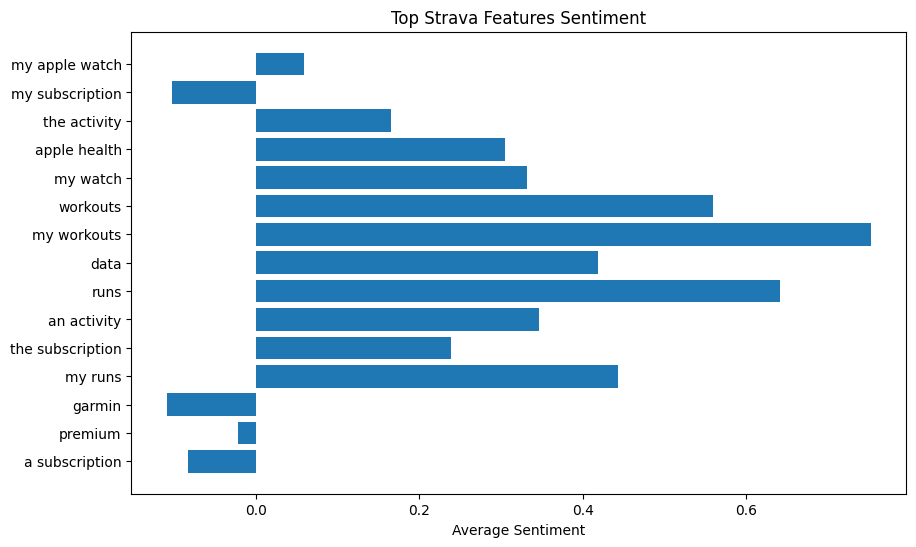

In [48]:
import matplotlib.pyplot as plt

top = feature_df.sort_values("count", ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(top["feature"], top["avg_sentiment"])
plt.title("Top Strava Features Sentiment")
plt.xlabel("Average Sentiment")
plt.show()